In [2]:
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------------------------------
# 1.1. DỮ LIỆU & SCENARIOS
# ---------------------------------------------------------
CLIENTS = ["C1", "C2", "C3", "C4", "C5"]
DEPOTS = ["D1", "D2", "D3"]

depot_data = {
    "D1": {"capacity": 100, "fixed_cost": 500},
    "D2": {"capacity": 150, "fixed_cost": 700},
    "D3": {"capacity": 250, "fixed_cost": 1200}
}
dist_matrix = {
    "C1": {"D1": 2, "D2": 5, "D3": 8}, "C2": {"D1": 3, "D2": 4, "D3": 7},
    "C3": {"D1": 6, "D2": 2, "D3": 5}, "C4": {"D1": 8, "D2": 3, "D3": 4},
    "C5": {"D1": 9, "D2": 6, "D3": 2}
}
TRANSPORT_COST = 1.5
PENALTY_COST = 50.0  # Phạt nặng khi Stock-out

SCENARIOS = {
    "Normal": {"prob": 0.6, "mult": 1.0, "color": "#6A7B58"}, # Xanh rêu
    "Peak":   {"prob": 0.3, "mult": 1.5, "color": "#B66D46"}, # Cam đất
    "Crisis": {"prob": 0.1, "mult": 2.5, "color": "#9B4444"}  # Đỏ đô
}
base_demand = {"C1": 20, "C2": 30, "C3": 25, "C4": 40, "C5": 35}
demand_scen = {w: {i: base_demand[i] * SCENARIOS[w]["mult"] for i in CLIENTS} for w in SCENARIOS}

# ---------------------------------------------------------
# 1.2. MÔ HÌNH TWO-STAGE STOCHASTIC PROGRAMMING
# ---------------------------------------------------------
model = pulp.LpProblem("SFLP_Two_Stage", pulp.LpMinimize)

# Stage 1 Variables (Độc lập với kịch bản)
y = pulp.LpVariable.dicts("Open", DEPOTS, cat="Binary")

# Stage 2 Variables (Phụ thuộc kịch bản w)
x = pulp.LpVariable.dicts("Flow", (CLIENTS, DEPOTS, SCENARIOS.keys()), lowBound=0, cat="Continuous")
s = pulp.LpVariable.dicts("Shortage", (CLIENTS, SCENARIOS.keys()), lowBound=0, cat="Continuous")

# Hàm mục tiêu (Fixed Cost + Expected Operational & Penalty Cost)
model += (
    pulp.lpSum(depot_data[j]["fixed_cost"] * y[j] for j in DEPOTS) +
    pulp.lpSum(SCENARIOS[w]["prob"] * (
        pulp.lpSum(TRANSPORT_COST * dist_matrix[i][j] * x[i][j][w] for i in CLIENTS for j in DEPOTS) +
        pulp.lpSum(PENALTY_COST * s[i][w] for i in CLIENTS)
    ) for w in SCENARIOS)
)

# Ràng buộc Giai đoạn 2 (Thỏa mãn nhu cầu & Nằm trong giới hạn công suất)
for w in SCENARIOS:
    for i in CLIENTS:
        model += pulp.lpSum(x[i][j][w] for j in DEPOTS) + s[i][w] == demand_scen[w][i]
    for j in DEPOTS:
        model += pulp.lpSum(x[i][j][w] for i in CLIENTS) <= depot_data[j]["capacity"] * y[j]

# ---------------------------------------------------------
# 1.3. GIẢI VÀ IN QUYẾT ĐỊNH GIAI ĐOẠN 1
# ---------------------------------------------------------
model.solve(pulp.PULP_CBC_CMD(msg=False))

print("="*50)
print("📌 GIAI ĐOẠN 1: QUYẾT ĐỊNH ĐẦU TƯ (HERE-AND-NOW)")
print("="*50)
print(f"Tổng chi phí kỳ vọng (Expected TCO): ${pulp.value(model.objective):,.2f}\n")

opened_depots = [j for j in DEPOTS if pulp.value(y[j]) > 0.5]
total_cap = sum(depot_data[j]['capacity'] for j in opened_depots)

for j in DEPOTS:
    status = "✅ XÂY MỚI" if j in opened_depots else "❌ BỎ QUA"
    print(f"[{status}] Kho {j} | Sức chứa: {depot_data[j]['capacity']} | Phí đầu tư: ${depot_data[j]['fixed_cost']}")
print(f"\n=> Tổng công suất chốt hạ: {total_cap} đơn vị hàng.")

📌 GIAI ĐOẠN 1: QUYẾT ĐỊNH ĐẦU TƯ (HERE-AND-NOW)
Tổng chi phí kỳ vọng (Expected TCO): $2,723.88

[✅ XÂY MỚI] Kho D1 | Sức chứa: 100 | Phí đầu tư: $500
[✅ XÂY MỚI] Kho D2 | Sức chứa: 150 | Phí đầu tư: $700
[❌ BỎ QUA] Kho D3 | Sức chứa: 250 | Phí đầu tư: $1200

=> Tổng công suất chốt hạ: 250 đơn vị hàng.


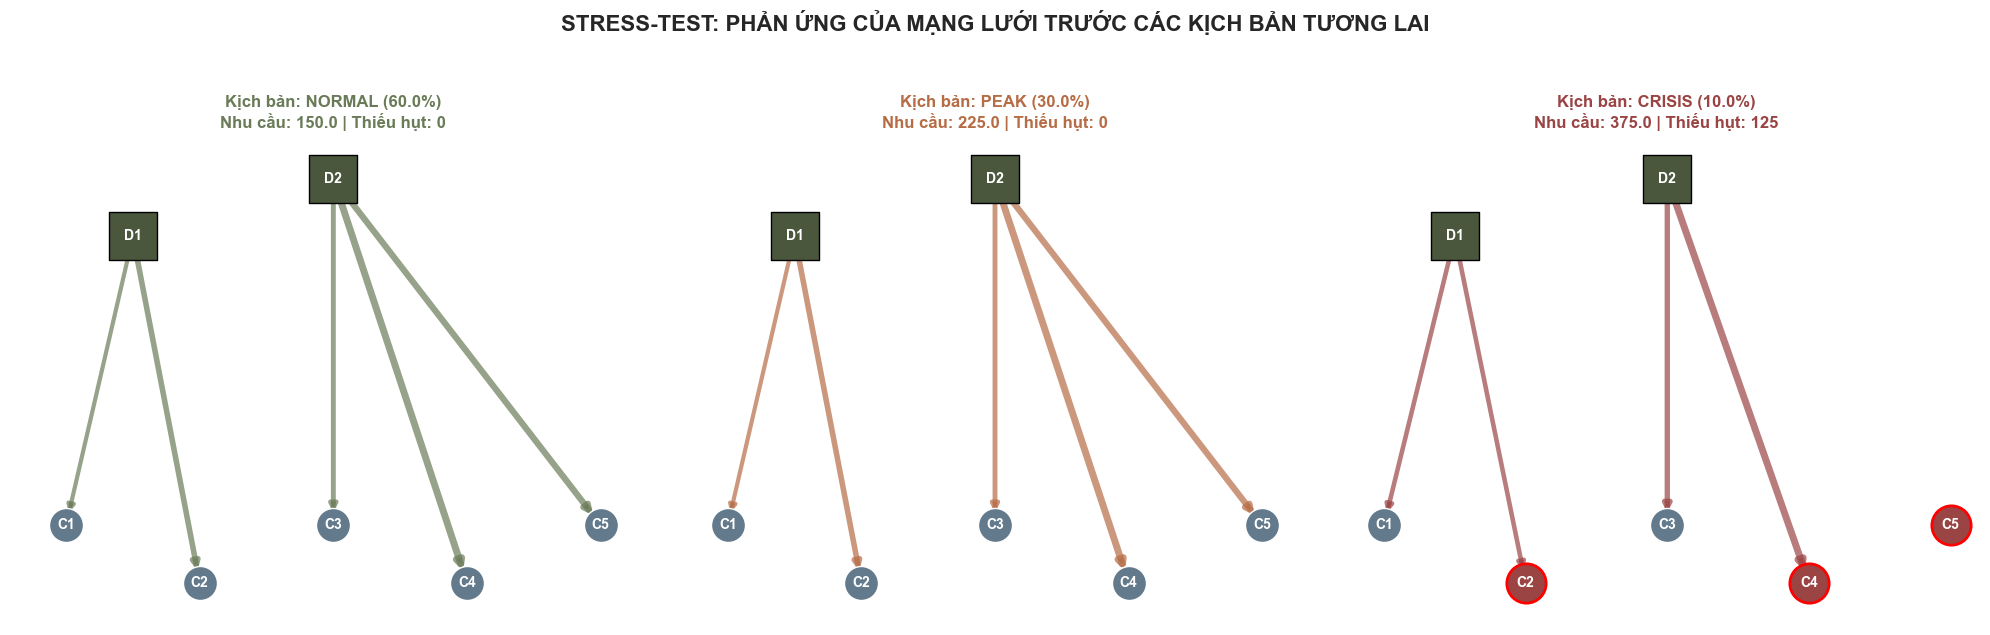

In [3]:
# ---------------------------------------------------------
# 2. TRỰC QUAN HÓA CÁC VŨ TRỤ SONG SONG (WAIT-AND-SEE)
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("STRESS-TEST: PHẢN ỨNG CỦA MẠNG LƯỚI TRƯỚC CÁC KỊCH BẢN TƯƠNG LAI", fontsize=16, fontweight='bold', y=1.05)

node_coords = {"D1": (2, 8), "D2": (5, 9), "D3": (8, 8), 
               "C1": (1, 3), "C2": (3, 2), "C3": (5, 3), "C4": (7, 2), "C5": (9, 3)}

scenario_stats = {}

for idx, (w, ax) in enumerate(zip(SCENARIOS.keys(), axes)):
    G = nx.DiGraph()
    G.add_nodes_from(DEPOTS)
    G.add_nodes_from(CLIENTS)
    
    edges = []
    edge_weights = []
    shortage_nodes = []
    total_shortage = 0
    total_demand = sum(demand_scen[w].values())
    
    # Rút trích luồng hàng và tình trạng thiếu hụt
    for i in CLIENTS:
        short_val = pulp.value(s[i][w])
        total_shortage += short_val
        if short_val > 0.1:
            shortage_nodes.append(i)
            
        for j in opened_depots:
            flow = pulp.value(x[i][j][w])
            if flow > 0.1:
                edges.append((j, i))
                edge_weights.append(flow)
                
    scenario_stats[w] = {"demand": total_demand, "shortage": total_shortage}
                
    # Vẽ các nút (Kho và Khách hàng)
    nx.draw_networkx_nodes(G, node_coords, nodelist=opened_depots, node_color="#4A573D", 
                           node_shape="s", node_size=1200, ax=ax, edgecolors="black")
    nx.draw_networkx_nodes(G, node_coords, nodelist=CLIENTS, node_color="#637A8C", 
                           node_shape="o", node_size=600, ax=ax, edgecolors="white")
    
    # Highlight các khách hàng bị đứt gãy cung ứng (Stock-out)
    if shortage_nodes:
        nx.draw_networkx_nodes(G, node_coords, nodelist=shortage_nodes, node_color="#9B4444", 
                               node_shape="o", node_size=800, ax=ax, edgecolors="red", linewidths=2)
    
    # Vẽ luồng phân phối
    if edges:
        max_w = max(edge_weights)
        widths = [(weight / max_w) * 4 + 1 for weight in edge_weights]
        nx.draw_networkx_edges(G, node_coords, edgelist=edges, width=widths, 
                               edge_color=SCENARIOS[w]["color"], alpha=0.7, arrows=True, ax=ax)
    
    nx.draw_networkx_labels(G, node_coords, font_size=10, font_weight="bold", font_color="white", ax=ax)
    
    # Đóng khung thông số từng kịch bản
    title = f"Kịch bản: {w.upper()} ({SCENARIOS[w]['prob']*100}%)\n"
    title += f"Nhu cầu: {total_demand} | Thiếu hụt: {total_shortage:.0f}"
    ax.set_title(title, fontsize=12, fontweight='bold', color=SCENARIOS[w]["color"])
    ax.axis('off')

plt.tight_layout()
plt.show()

🚀 Đánh giá khả năng đáp ứng của mạng lưới
📊 Tình hình hiện tại
- Mạng lưới hiện vẫn còn khoảng 40% công suất dự phòng, đủ để hấp thụ các biến động nhu cầu thông thường.
- Xác suất xảy ra tình trạng thiếu năng lực phục vụ ở mức khoảng 10%.
- Trung bình kỳ vọng sẽ thiếu khoảng 12,5 đơn vị hàng hóa nếu xuất hiện các tình huống bất lợi.
Kết luận nhanh

💡 Trong điều kiện vận hành bình thường và cả giai đoạn cao điểm, mạng lưới vẫn đáp ứng tốt nhu cầu thị trường. Tuy nhiên, khi xuất hiện các kịch bản khủng hoảng hoặc nhu cầu tăng đột biến, một số khách hàng có nguy cơ không được phục vụ đầy đủ.

⚠️ Rủi ro cần lưu ý

Biểu đồ cho thấy:

- Kịch bản Normal (60%): Hệ thống đáp ứng 100% nhu cầu.
- Kịch bản Peak (30%): Hệ thống vẫn đáp ứng được toàn bộ nhu cầu nhưng phải tận dụng tối đa công suất hiện có.
- Kịch bản Crisis (10%): Nhu cầu vượt quá khả năng phục vụ, dẫn đến thiếu hụt khoảng 125 đơn vị hàng hóa. Các khách hàng như C2, C4 và C5 là những điểm có nguy cơ bị ảnh hưởng trước.
💡 Khuyến nghị hành động
1. Chưa cần đầu tư thêm kho mới

Hiện tại chi phí xây dựng hoặc mở thêm kho chưa thực sự mang lại hiệu quả kinh tế vì các tình huống thiếu hụt chỉ xảy ra trong một tỷ lệ nhỏ các kịch bản.

💡 Khuyến nghị:
- Giữ nguyên cấu trúc mạng lưới hiện tại.
- Theo dõi tăng trưởng nhu cầu định kỳ để đánh giá lại trong tương lai.

2. Chuẩn bị phương án dự phòng khi nhu cầu tăng đột biến

- Thay vì đầu tư cố định với chi phí lớn, nên chuẩn bị sẵn các nguồn lực có thể kích hoạt nhanh khi cần.

Nên thực hiện:

- Ký sẵn hợp đồng với đối tác logistics (3PL).
- Chuẩn bị phương án thuê thêm xe tải hoặc kho tạm thời theo nhu cầu.
- Chỉ kích hoạt các nguồn lực này khi xuất hiện kịch bản Peak hoặc Crisis.

🚀 Lợi ích: Giảm rủi ro thiếu hàng nhưng vẫn kiểm soát được chi phí vận hành.

3. Tối ưu vận chuyển trong mùa cao điểm

- Khi nhu cầu tăng cao, một số khách hàng có thể được phục vụ từ các kho xa hơn thay vì kho gần nhất.

- Điều này giúp duy trì mức độ phục vụ nhưng có thể làm chi phí vận tải tăng mạnh.

💡 Khuyến nghị:

- Gom đơn hàng và tối ưu tuyến giao hàng thay vì giao riêng lẻ.
- Xem xét triển khai mô hình tối ưu vị trí kho kết hợp định tuyến vận tải (Location-Routing).
- Ưu tiên các chuyến xe đầy tải để giảm chi phí phát sinh trong mùa cao điểm.